<a href="https://colab.research.google.com/github/msiplab/EicEngLabIV/blob/master/example01_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 実験Ⅳ－１　重回帰モデル

1. サンプルデータの読み込み
1. 線形重回帰の実行
1. 基底展開重回帰の実行



In [1]:
!pip install japanize-matplotlib
%matplotlib inline

import warnings
warnings.simplefilter('ignore') #警告を無視（コメントアウト推奨）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib #日本語化matplotlib
sns.set(font="IPAexGothic") #日本語フォント設定


## Colab向け: セル内に観測データを直接定義

ファイルアップロードなしで実行できるように、観測データをノート内に直接記述します。

In [2]:
# このノートではファイル読み込みを使わず、次セルでデータを直接定義します。

In [4]:
# 個人ワーク2用データ（practice01_08.csv）をセル内に直接定義
dataset = pd.DataFrame(
    [
        [0.00052, 0, 434, 442, 466, 478, 485, 490, 493, 496, 502, 509, 517, 525, 534, 542, 550, 559, 570],
        [0.0008, 0, 403, 405, 417, 432, 444, 452, 458, 461, 462, 464, 467, 471, 471, 475, 478, 482, 489],
        [0.001, 0, 378, 381, 378, 388, 411, 424, 431, 435, 438, 436, 438, 440, 443, 445, 448, 450, 453],
        [0.001, 0, 381, 385, 383, 402, 421, 431, 437, 441, 444, 445, 447, 448, 449, 451, 453, 455, 458],
        [0.002, 0, 328, 331, 335, 338, 341, 344, 347, 351, 353, 356, 358, 360, 361, 363, 365, 367, 371],
        [0.003, 0, 301, 307, 311, 313, 316, 319, 321, 324, 326, 328, 329, 330, 331, 333, 334, 336, 340],
        [0.005, 0, 274, 281, 286, 288, 290, 292, 294, 295, 297, 298, 299, 300, 301, 303, 304, 306, 308],
        [0.006, 0, 269, 275, 281, 282, 285, 287, 289, 291, 293, 294, 296, 297, 298, 299, 300, 302, 304],
        [0.009, 0, 258, 262, 268, 269, 271, 273, 275, 276, 277, 278, 279, 280, 281, 282, 282, 283, 285],
    ],
    columns=['圧力[Torr]', '0', '25', '50', '100', '150', '200', '250', '300', '350', '400', '450', '500', '550', '600', '650', '700', '750', '800']
)
display(dataset)


,圧力[Torr],0,25,50,100,150,200,250,300,350,400,450,500,550,600,650,700,750,800
0,0.00052,0,434,442,466,478,485,490,493,496,502,509,517,525,534,542,550,559,570
1,0.00080,0,403,405,417,432,444,452,458,461,462,464,467,471,471,475,478,482,489
2,0.00100,0,378,381,378,388,411,424,431,435,438,436,438,440,443,445,448,450,453
3,0.00100,0,381,385,383,402,421,431,437,441,444,445,447,448,449,451,453,455,458
4,0.00200,0,328,331,335,338,341,344,347,351,353,356,358,360,361,363,365,367,371
5,0.00300,0,301,307,311,313,316,319,321,324,326,328,329,330,331,333,334,336,340
6,0.00500,0,274,281,286,288,290,292,294,295,297,298,299,300,301,303,304,306,308
7,0.00600,0,269,275,281,282,285,287,289,291,293,294,296,297,298,299,300,302,304
8,0.00900,0,258,262,268,269,271,273,275,276,277,278,279,280,281,282,282,283,285


## データの整形

以下では、二次元テーブルデータの読み込みを想定しています。

1. 説明変数の整形（メッシュグリッド化）
1. 目的変数の抽出


In [5]:
# 説明変数x1（ヘッダの読み込み）
x1 = dataset.columns[1:].astype(float).values
display(x1)
# 説明変数x2（１列目の読み込み）
x2 = dataset.iloc[:,0].astype(float).values
display(x2)

# 説明変数x1,x2の設定（メッシュグリッド）
x1,x2 = np.meshgrid(x1,x2) 
display(x1)
display(x2)

# 目的変数yの設定
y = dataset.iloc[0:,1:].astype(float).values
display(y)

# 総観測点数の抽出
nSamples = y.size

array([  0.,  25.,  50., 100., 150., 200., 250., 300., 350., 400., 450.,
       500., 550., 600., 650., 700., 750., 800.])

array([0.00052, 0.0008 , 0.001  , 0.001  , 0.002  , 0.003  , 0.005  ,
       0.006  , 0.009  ])

array([[  0.,  25.,  50., 100., 150., 200., 250., 300., 350., 400., 450.,
        500., 550., 600., 650., 700., 750., 800.],
       [  0.,  25.,  50., 100., 150., 200., 250., 300., 350., 400., 450.,
        500., 550., 600., 650., 700., 750., 800.],
       [  0.,  25.,  50., 100., 150., 200., 250., 300., 350., 400., 450.,
        500., 550., 600., 650., 700., 750., 800.],
       [  0.,  25.,  50., 100., 150., 200., 250., 300., 350., 400., 450.,
        500., 550., 600., 650., 700., 750., 800.],
       [  0.,  25.,  50., 100., 150., 200., 250., 300., 350., 400., 450.,
        500., 550., 600., 650., 700., 750., 800.],
       [  0.,  25.,  50., 100., 150., 200., 250., 300., 350., 400., 450.,
        500., 550., 600., 650., 700., 750., 800.],
       [  0.,  25.,  50., 100., 150., 200., 250., 300., 350., 400., 450.,
        500., 550., 600., 650., 700., 750., 800.],
       [  0.,  25.,  50., 100., 150., 200., 250., 300., 350., 400., 450.,
        500., 550., 600., 650., 700., 750., 800.],


array([[0.00052, 0.00052, 0.00052, 0.00052, 0.00052, 0.00052, 0.00052,
        0.00052, 0.00052, 0.00052, 0.00052, 0.00052, 0.00052, 0.00052,
        0.00052, 0.00052, 0.00052, 0.00052],
       [0.0008 , 0.0008 , 0.0008 , 0.0008 , 0.0008 , 0.0008 , 0.0008 ,
        0.0008 , 0.0008 , 0.0008 , 0.0008 , 0.0008 , 0.0008 , 0.0008 ,
        0.0008 , 0.0008 , 0.0008 , 0.0008 ],
       [0.001  , 0.001  , 0.001  , 0.001  , 0.001  , 0.001  , 0.001  ,
        0.001  , 0.001  , 0.001  , 0.001  , 0.001  , 0.001  , 0.001  ,
        0.001  , 0.001  , 0.001  , 0.001  ],
       [0.001  , 0.001  , 0.001  , 0.001  , 0.001  , 0.001  , 0.001  ,
        0.001  , 0.001  , 0.001  , 0.001  , 0.001  , 0.001  , 0.001  ,
        0.001  , 0.001  , 0.001  , 0.001  ],
       [0.002  , 0.002  , 0.002  , 0.002  , 0.002  , 0.002  , 0.002  ,
        0.002  , 0.002  , 0.002  , 0.002  , 0.002  , 0.002  , 0.002  ,
        0.002  , 0.002  , 0.002  , 0.002  ],
       [0.003  , 0.003  , 0.003  , 0.003  , 0.003  , 0.003  , 0.0

array([[  0., 434., 442., 466., 478., 485., 490., 493., 496., 502., 509.,
        517., 525., 534., 542., 550., 559., 570.],
       [  0., 403., 405., 417., 432., 444., 452., 458., 461., 462., 464.,
        467., 471., 471., 475., 478., 482., 489.],
       [  0., 378., 381., 378., 388., 411., 424., 431., 435., 438., 436.,
        438., 440., 443., 445., 448., 450., 453.],
       [  0., 381., 385., 383., 402., 421., 431., 437., 441., 444., 445.,
        447., 448., 449., 451., 453., 455., 458.],
       [  0., 328., 331., 335., 338., 341., 344., 347., 351., 353., 356.,
        358., 360., 361., 363., 365., 367., 371.],
       [  0., 301., 307., 311., 313., 316., 319., 321., 324., 326., 328.,
        329., 330., 331., 333., 334., 336., 340.],
       [  0., 274., 281., 286., 288., 290., 292., 294., 295., 297., 298.,
        299., 300., 301., 303., 304., 306., 308.],
       [  0., 269., 275., 281., 282., 285., 287., 289., 291., 293., 294.,
        296., 297., 298., 299., 300., 302., 304.],


## 観測データの散布図
- データの値の範囲を抽出
- (x1,y), (x2,y)の散布図を描画


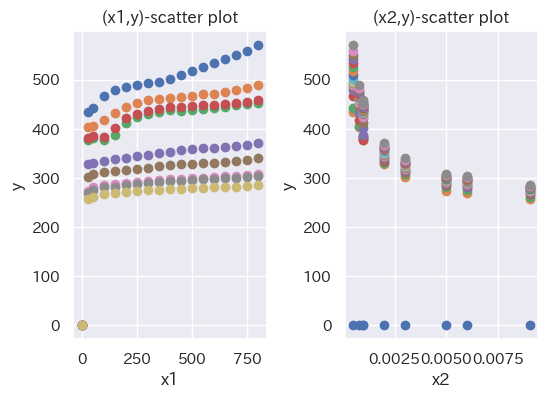

In [6]:
from mpl_toolkits import mplot3d

# 散布図の範囲情報の抽出
minx1 = np.min(x1)
maxx1 = np.max(x1)
rx1 = maxx1-minx1
cx1 = 0.5*rx1
minx2 = np.min(x2)
maxx2 = np.max(x2)
rx2 = maxx2-minx2
cx2 = 0.5*rx2

# 散布図の表示
fig, axs = plt.subplots(1, 2, figsize=(6,4))
plt.subplots_adjust(wspace=0.4, hspace=0.6)
# (x1,y)
for irow in range(y.shape[0]):
    axs[0].scatter(x1[irow,:],y[irow,:])
axs[0].set_title('(x1,y)-scatter plot')
axs[0].set_xlabel('x1')
axs[0].set_ylabel('y')
# (x2,y)
for icol in range(y.shape[1]):
    axs[1].scatter(x2[:,icol],y[:,icol])
axs[1].set_title('(x2,y)-scatter plot')
axs[1].set_xlabel('x2')
axs[1].set_ylabel('y')
#
axs[0].grid(True)
axs[1].grid(True)
plt.show()




# 三次元散布図の描画


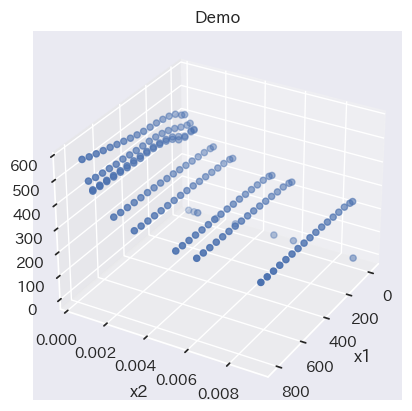

In [7]:

# 三次元散布図の表示
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.scatter(x1,x2,y)
ax.set_title('Demo')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_xlim([minx1-0.1*rx1,maxx1+0.1*rx1])
ax.set_ylim([minx2-0.1*rx2,maxx2+0.1*rx2])
ax.view_init(elev=30,azim=30) # 見やすいように設定
ax.grid(True)
plt.show()

## 線形重回帰の実行

- sklearn.linear_model.LinearRegression を利用

In [8]:
from sklearn.linear_model import LinearRegression

# 線形単回帰のインスタンス生成
regm = LinearRegression()

# 線形重回帰分析
Xdata = np.concatenate([x1.reshape(-1,1), x2.reshape(-1,1)],axis=1) # データ行列生成
ydata = y.reshape(-1,1) # 列ベクトル化
regm.fit(Xdata,ydata) # 最小２乗法

LinearRegression()

In [9]:
# 推定結果
beta0 = regm.intercept_[0]
beta1 = regm.coef_[0][0]
beta2 = regm.coef_[0][1]
print("β0 = {0:5.2f} ".format(beta0))
print("β1 = {0:5.2f} ".format(beta1))
print("β2 = {0:5.2f} ".format(beta2))
print(f"線形重回帰式: y = {beta0:.6e} + ({beta1:.6e})x1 + ({beta2:.6e})x2")
print("(x1: 放電電流[mA], x2: 圧力[Torr])")


β0 = 354.99 
β1 =  0.18 
β2 = -23261.61 
線形重回帰式: y = 3.549895e+02 + (1.843800e-01)x1 + (-2.326161e+04)x2
(x1: 放電電流[mA], x2: 圧力[Torr])


### 3次元散布図と曲面の表示

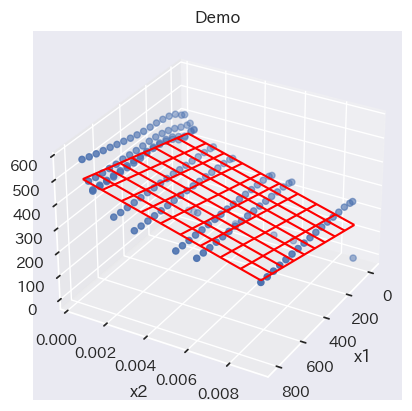

In [10]:
nPoints = 10
fig = plt.figure()
ax = plt.axes(projection='3d')
xfit1,xfit2 = np.meshgrid(np.linspace(minx1,maxx1,nPoints),
                          np.linspace(minx2,maxx2,nPoints))
Xfit  = np.concatenate([xfit1.reshape(-1,1),xfit2.reshape(-1,1)],axis=1)
yfit  = regm.predict(Xfit).reshape(xfit1.shape)
ax.scatter(x1,x2,y)
ax.plot_wireframe(xfit1,xfit2,yfit, color = 'red')
ax.set_title('Demo')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_xlim([minx1-0.1*rx1,maxx1+0.1*rx1])
ax.set_ylim([minx2-0.1*rx2,maxx2+0.1*rx2])
ax.view_init(elev=30,azim=30) # 見やすいように設定
ax.grid(True)
plt.show()

## 基底展開重回帰モデルのパラメータ数の選択

- 多項式重回帰(sklearn.preprocessing.PolynomialFeaturessを利用)
- RBF重回帰（K平均法を利用した2段階推定クラスを定義）


In [11]:
"""GaussianFeaturesWithKmenasモジュール

    Copyright (c) 2020, Shogo MURAMATSU, All rights reserved.
"""
import numpy as np
import pandas as pd 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.base import BaseEstimator, TransformerMixin

class GaussianFeaturesWithKmeans(BaseEstimator, TransformerMixin):
    """K平均法を利用した2段階推定法によるガウス基底関数

        scikit-learn LinearRegression推定器に渡すためのガウス基底関数による
        特徴量への変換クラス    

    Attirbutes:
        nbfs (int): 基底関数の数
        centers_ (numpy.ndarray): 各ガウス関数の中心
        widths_ (numpy.ndarray): 各ガウス関数の幅

    References:

        * 小西貞則「多変量解析入門－線形から非線形へ－」岩波書店
        * Jake VanderPlas（菊池彰訳）「Pythonデータサイエンスハンドブック」オライリージャパン
    """
    def __init__(self, nbfs, width_factor=1.0, prekmeans=True):
        """GaussianFeaturesWithKMeansのコンストラクタ"""
        self.nbfs = nbfs
        self.width_factor = width_factor
        self.prekmeans = prekmeans

    @staticmethod
    def _gauss_basis(x, y, width, axis=None):
        arg = (x - y) / (width + 1e-300)
        return np.exp(-0.5 * np.sum(arg ** 2, axis))

    def fit(self, X, y=None):
        ndims = X.shape[1]
        if self.prekmeans: # K平均法を前処理に利用
            # 説明変数の標準化とK平均法の実行
            scaler = StandardScaler()         
            kmeans = KMeans(n_clusters=self.nbfs,random_state=0)
            X = scaler.fit_transform(X) 
            kmeans.fit(X) 
            # クラスタラベルの抽出
            labels = kmeans.predict(X).reshape(-1,1)            
            # 各クラスタの中心と幅を抽出
            clusters = pd.DataFrame(np.concatenate((labels,X),axis=1)).groupby([0])
            centers = scaler.inverse_transform(kmeans.cluster_centers_) 
            widths = (self.width_factor * scaler.scale_ * clusters.std(ddof=0)).to_numpy()
            #プライベート静的メソッド_gauss_basisでブロードキャスト計算するために成形
            if ndims == 1:
                self.centers_ = centers.reshape(-1,)
                self.widths_ = widths.reshape(-1,)
            else:
                self.centers_ = centers.reshape(-1,ndims,1).transpose(2,1,0) 
                self.widths_ = widths.reshape(-1,ndims,1).transpose(2,1,0)
        else: # 等間隔にガウス基底を配置（単変量のみ）
            if ndims == 1:
                centers = np.linspace(X.min(), X.max(), self.nbfs) 
                self.centers_ = centers
                self.widths_ = self.width_factor * (centers[1] - centers[0]) * np.ones(self.nbfs)
            else:
                raise Exception('prekmeansを True に設定してください．重回帰はK平均法による事前推定のみ対応しています．') 
        
        return self
        
    def transform(self, X):
        return self._gauss_basis(X[:,:, np.newaxis], self.centers_,
                                self.widths_, axis=1)

### 重回帰モデルの評価

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# RFB重回帰の選択
isRBF = not True # False の場合は多項式重回帰を選択
width_factor = 2.0 # ガウス関数の広さ

# 評価する基底数の最大値
maxdeg = 50

# モデル評価
deg = np.zeros(maxdeg,dtype=int)
aic = np.zeros(maxdeg)
regmp = [ [] for idx in range(maxdeg) ]
for idx in range(maxdeg):
    deg[idx] = idx+1

    # 基底展開法の特徴量を選択
    if isRBF: # RBF重回帰モデル
        phi = GaussianFeaturesWithKmeans(nbfs=deg[idx],width_factor=width_factor)
    else: #多項式重回帰モデル
        phi = PolynomialFeatures(degree=deg[idx],include_bias=False)
        
    # 基底展開重回帰モデルのインスタンス生成
    regmp[idx] = make_pipeline(phi,LinearRegression())
    # 基底展開重回帰分析
    regmp[idx].fit(Xdata,ydata)

    # AIC
    ypred = regmp[idx].predict(Xdata)
    mse = mean_squared_error(y.reshape(-1,1),ypred)
    if isRBF: # RBF重回帰モデル
        nCoefs = deg[idx]+1
    else: # 多項式重回帰モデル
        nCoefs = (deg[idx]+1)*(deg[idx]+2)/2 # (n+1)(n+2)/2
    aic[idx] = nSamples*np.log(2*np.pi*mse)+nSamples+2*(nCoefs+1)
    print("deg = {0:d}: AIC = {1:5.2e} ".format(deg[idx],aic[idx]))




deg = 1: AIC = 1.91e+03 
deg = 2: AIC = 1.85e+03 
deg = 3: AIC = 1.83e+03 
deg = 4: AIC = 1.81e+03 
deg = 5: AIC = 1.81e+03 
deg = 6: AIC = 1.95e+03 
deg = 7: AIC = 1.98e+03 
deg = 8: AIC = 2.01e+03 
deg = 9: AIC = 2.04e+03 
deg = 10: AIC = 2.07e+03 
deg = 11: AIC = 2.11e+03 
deg = 12: AIC = 2.14e+03 
deg = 13: AIC = 2.17e+03 
deg = 14: AIC = 2.21e+03 
deg = 15: AIC = 2.24e+03 
deg = 16: AIC = 2.28e+03 
deg = 17: AIC = 2.31e+03 
deg = 18: AIC = 2.35e+03 
deg = 19: AIC = 2.39e+03 
deg = 20: AIC = 2.44e+03 
deg = 21: AIC = 2.48e+03 
deg = 22: AIC = 2.53e+03 
deg = 23: AIC = 2.58e+03 
deg = 24: AIC = 2.63e+03 
deg = 25: AIC = 2.68e+03 
deg = 26: AIC = 2.74e+03 
deg = 27: AIC = 2.79e+03 
deg = 28: AIC = 2.85e+03 
deg = 29: AIC = 2.91e+03 
deg = 30: AIC = 2.98e+03 
deg = 31: AIC = 3.04e+03 
deg = 32: AIC = 3.11e+03 
deg = 33: AIC = 3.18e+03 
deg = 34: AIC = 3.25e+03 
deg = 35: AIC = 3.32e+03 
deg = 36: AIC = 3.39e+03 
deg = 37: AIC = 3.47e+03 
deg = 38: AIC = 3.55e+03 
deg = 39: AIC = 3.63e

### AICのプロット

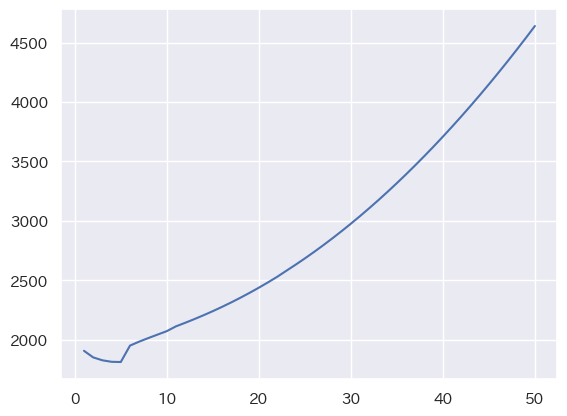

In [13]:
fig, ax = plt.subplots()
ax.plot(deg,aic)
plt.show()

### 最小AICモデルの選択

In [14]:
# 最小のAICを与えるモデルのインデックス
optidx = np.argmin(aic)
# 最小のAICを与える次数
degopt = deg[optidx]
# 最適な基底展開重回帰のインスタンス抽出
regmpopt = regmp[optidx]
# 最適なパラメータ数
if isRBF: # RGB重回帰モデルのパラメータ数
    nCoefsOpt = int(degopt + 1)
else: # 多項式重回帰モデルのパラメータ数 
    nCoefsOpt = int((degopt+1)*(degopt+2)/2) # (n+1)(n+2)/2

print(f"AIC最小次数 degopt = {degopt}")
print(f"最適パラメータ数 = {nCoefsOpt}")
print(f"AIC最小値 = {aic[optidx]:.6e}")

AIC最小次数 degopt = 5
最適パラメータ数 = 21
AIC最小値 = 1.812504e+03


In [15]:
# 最適パラメータの推定結果
w0 = regmpopt[1].intercept_[0]
print("w0 = {0:5.2f} ".format(w0))
for idx in range(0,nCoefsOpt-1):
    w = regmpopt[1].coef_[0][idx]
    print("w{0:d} = {1:5.2f} ".format(idx+1,w))

if isRBF:
    print("RBFモデルのため、回帰式は基底関数の線形結合で表されます。")
else:
    feature_names = regmpopt[0].get_feature_names_out(['x1','x2'])
    terms = [f"{w0:.6e}"]
    for name, coef in zip(feature_names, regmpopt[1].coef_[0]):
        terms.append(f"({coef:.6e}){name}")
    print("基底展開重回帰式: y = " + " + ".join(terms))
    print("(x1: 放電電流[mA], x2: 圧力[Torr])")

w0 = 96.57 
w1 =  5.69 
w2 = -0.00 
w3 = -0.04 
w4 =  0.01 
w5 = -0.00 
w6 =  0.00 
w7 = -0.73 
w8 =  0.00 
w9 = -0.00 
w10 = -0.00 
w11 =  0.00 
w12 = -0.01 
w13 =  0.00 
w14 = -0.00 
w15 =  0.00 
w16 = -0.00 
w17 =  0.02 
w18 = -0.00 
w19 =  0.00 
w20 = -0.00 
基底展開重回帰式: y = 9.657366e+01 + (5.686685e+00)x1 + (-1.872557e-04)x2 + (-3.511508e-02)x1^2 + (1.319582e-02)x1 x2 + (-2.024622e-07)x2^2 + (9.877518e-05)x1^3 + (-7.335362e-01)x1^2 x2 + (5.810146e-05)x1 x2^2 + (-1.703902e-09)x2^3 + (-1.252400e-07)x1^4 + (1.714273e-03)x1^3 x2 + (-6.486852e-03)x1^2 x2^2 + (3.523579e-07)x1 x2^3 + (-1.445058e-11)x2^4 + (5.849199e-11)x1^5 + (-1.276745e-06)x1^4 x2 + (1.794096e-02)x1^3 x2^2 + (-5.397605e-05)x1^2 x2^3 + (2.475838e-09)x1 x2^4 + (-1.248690e-13)x2^5
(x1: 放電電流[mA], x2: 圧力[Torr])


### 3次元散布図と曲面の表示

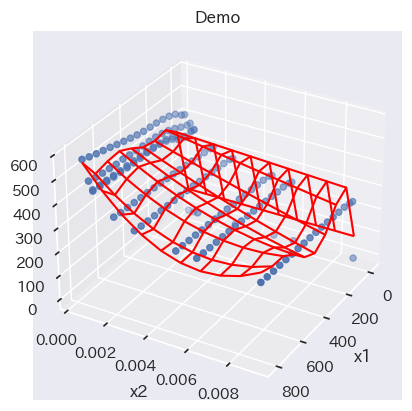

In [16]:

fig = plt.figure()
ax = plt.axes(projection='3d')
yfit = regmpopt.predict(Xfit).reshape(xfit1.shape)
ax.scatter(x1,x2,y)
ax.plot_wireframe(xfit1,xfit2,yfit, color = 'red')
ax.set_title('Demo')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_xlim([minx1-0.1*rx1,maxx1+0.1*rx1])
ax.set_ylim([minx2-0.1*rx2,maxx2+0.1*rx2])
ax.view_init(elev=30,azim=30) # 見やすいように設定
ax.grid(True)
plt.show()